# CIFAR-100 Classification with ResNetV2

In [19]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sympy import factor
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast
from collections import OrderedDict


# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


os.makedirs('generated_images', exist_ok=True)
os.makedirs('saved_models', exist_ok=True)

Using device: cuda


## Data Loading and Preprocessing

In [20]:
def get_cifar100_loaders(batch_size=128):
    """Returns CIFAR-100 train and test loaders with appropriate transforms"""
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                             std=[0.2675, 0.2565, 0.2761]),
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                             std=[0.2675, 0.2565, 0.2761]),
    ])

    train_set = torchvision.datasets.CIFAR100(
        root='./data', train=True, download=True, transform=train_transform)
    test_set = torchvision.datasets.CIFAR100(
        root='./data', train=False, download=True, transform=test_transform)

    train_loader = DataLoader(train_set, batch_size=batch_size,
                              shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size,
                             shuffle=False, num_workers=4, pin_memory=True)

    return train_loader, test_loader

## Model Architecture

In [21]:
class StdConv2d(nn.Conv2d):
    def forward(self, x):
        w = self.weight
        v, m = torch.var_mean(w, dim=[1, 2, 3], keepdim=True, unbiased=False)
        w = (w - m) / torch.sqrt(v + 1e-10)
        return nn.functional.conv2d(
            x, w, self.bias, self.stride, self.padding,
            self.dilation, self.groups)


def conv3x3(cin, cout, stride=1, groups=1, bias=False):
    return StdConv2d(cin, cout, kernel_size=3, stride=stride,
                     padding=1, bias=bias, groups=groups)


def conv1x1(cin, cout, stride=1, bias=False):
    return StdConv2d(cin, cout, kernel_size=1, stride=stride,
                     padding=0, bias=bias)




In [22]:
class PreActBottleneck(nn.Module):
    def __init__(self, cin, cout=None, cmid=None, stride=1):
        super().__init__()
        cout = cout or cin
        cmid = cmid or cout // 4

        self.gn1 = nn.GroupNorm(32, cin)
        self.conv1 = conv1x1(cin, cmid)
        self.gn2 = nn.GroupNorm(32, cmid)
        self.conv2 = conv3x3(cmid, cmid, stride)
        self.gn3 = nn.GroupNorm(32, cmid)
        self.conv3 = conv1x1(cmid, cout)
        self.relu = nn.ReLU(inplace=True)

        if stride != 1 or cin != cout:
            self.downsample = conv1x1(cin, cout, stride)

    def forward(self, x):
        out = self.relu(self.gn1(x))
        residual = x
        if hasattr(self, 'downsample'):
            residual = self.downsample(out)

        out = self.conv1(out)
        out = self.conv2(self.relu(self.gn2(out)))
        out = self.conv3(self.relu(self.gn3(out)))

        return out + residual



In [23]:
class ResNetV2(nn.Module):
    BLOCK_UNITS = {'r50': [3, 4, 6, 3]}

    def __init__(self, block_units, width_factor=1, num_classes=100):
        super().__init__()
        wf = width_factor

        # Modified root for CIFAR-100 (32x32)
        self.root = nn.Sequential(OrderedDict([
            ('conv', StdConv2d(3, 64 * wf, kernel_size=3, stride=1, padding=1, bias=False)),
            ('gn', nn.GroupNorm(32, 64 * wf)),
            ('relu', nn.ReLU(inplace=True)),
        ]))

        self.body = nn.Sequential(OrderedDict([
            ('block1', self._make_block(64 * wf, 256 * wf, block_units[0], stride=1)),
            ('block2', self._make_block(256 * wf, 512 * wf, block_units[1], stride=2)),
            ('block3', self._make_block(512 * wf, 1024 * wf, block_units[2], stride=2)),
            ('block4', self._make_block(1024 * wf, 2048 * wf, block_units[3], stride=2)),
        ]))

        self.head = nn.Sequential(OrderedDict([
            ('gn', nn.GroupNorm(32, 2048 * wf)),
            ('relu', nn.ReLU(inplace=True)),
            ('avg', nn.AdaptiveAvgPool2d(1)),
            ('flatten', nn.Flatten()),
            ('fc', nn.Linear(2048 * wf, num_classes)),
        ]))

    def _make_block(self, cin, cout, units, stride):
        layers = [PreActBottleneck(cin, cout, stride=stride)]
        for _ in range(1, units):
            layers.append(PreActBottleneck(cout, cout))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.root(x)
        x = self.body(x)
        x = self.head(x)
        return x

## Training and Evaluation

In [24]:
def evaluate(model, test_loader, criterion):
    """Evaluate model performance on test set"""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return total_loss / len(test_loader), 100 * correct / total



In [25]:
def train_model():
    """Complete training procedure"""
    # Hyperparameters
    batch_size = 128
    epochs = 1000
    lr = lr=1e-3
    weight_decay = 1e-3
    patience = 15

    # Data
    train_loader, test_loader = get_cifar100_loaders(batch_size)

    # Model
    model = ResNetV2(ResNetV2.BLOCK_UNITS['r50'], width_factor=1).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = GradScaler()

    # Tracking
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    early_stop_counter = 0

    # Training loop
    for epoch in range(epochs):
        model.train()
        epoch_loss, correct, total = 0.0, 0, 0

        for inputs, targets in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}'):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()

            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        # Validation
        val_loss, val_acc = evaluate(model, test_loader, criterion)
        train_acc = 100 * correct / total

        # Update tracking
        train_losses.append(epoch_loss / len(train_loader))
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        scheduler.step()
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            model_path = 'saved_models/best_model.pth'
            torch.save(model.state_dict(), model_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch + 1}")
                break

        # Logging
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print(f"Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
        print(f"LR: {optimizer.param_groups[0]['lr']:.2e}")
        print("-" * 50)

    # Plotting
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(train_losses, label='Train')
    ax.plot(val_losses, label='Validation')
    ax.set_title('Loss Curve')
    ax.legend()

    plt.tight_layout()
    path = 'generated_images/loss_function.png'
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    return model


## Visualization

In [26]:
def visualize_predictions(model, test_loader, num_images=25):
    """Visualize model predictions with ground truth"""
    # Load class names
    with open('data/cifar-100-python/meta', 'rb') as f:
        class_names = pickle.load(f)['fine_label_names']

    # Get predictions
    model.eval()
    images, labels = next(iter(test_loader))
    with torch.no_grad():
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)

    # Denormalize
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1)
    images = images * std + mean
    images = torch.clamp(images, 0, 1)

    # Plot
    plt.figure(figsize=(12, 12))
    for idx in range(min(num_images, len(images))):
        plt.subplot(5, 5, idx + 1)
        plt.imshow(images[idx].permute(1, 2, 0).cpu())
        true_name = class_names[labels[idx]]
        pred_name = class_names[preds[idx]]
        color = 'green' if labels[idx] == preds[idx] else 'red'
        plt.title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    path = 'generated_images/label_predictions.png'
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()

Files already downloaded and verified
Files already downloaded and verified


Epoch 1/1000: 100%|██████████| 391/391 [01:15<00:00,  5.19it/s]



Epoch 1/1000
Train Loss: 4.0486 | Val Loss: 3.6279
Train Acc: 9.67% | Val Acc: 17.81%
LR: 1.00e-03
--------------------------------------------------


Epoch 2/1000: 100%|██████████| 391/391 [01:17<00:00,  5.08it/s]



Epoch 2/1000
Train Loss: 3.2900 | Val Loss: 3.1008
Train Acc: 25.48% | Val Acc: 31.23%
LR: 1.00e-03
--------------------------------------------------


...


Epoch 69/1000
Train Loss: 0.8402 | Val Loss: 1.7017
Train Acc: 99.09% | Val Acc: 73.65%
LR: 9.88e-04
--------------------------------------------------


Epoch 70/1000: 100%|██████████| 391/391 [01:24<00:00,  4.62it/s]



Epoch 70/1000
Train Loss: 0.8359 | Val Loss: 1.7298
Train Acc: 99.22% | Val Acc: 73.12%
LR: 9.88e-04
--------------------------------------------------


Epoch 71/1000: 100%|██████████| 391/391 [01:24<00:00,  4.60it/s]



Early stopping at epoch 71


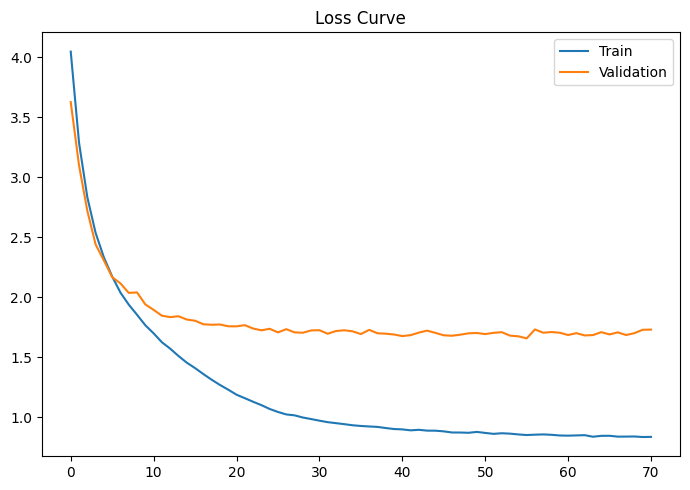

Best Validation Accuracy: 74.30%
Files already downloaded and verified
Files already downloaded and verified


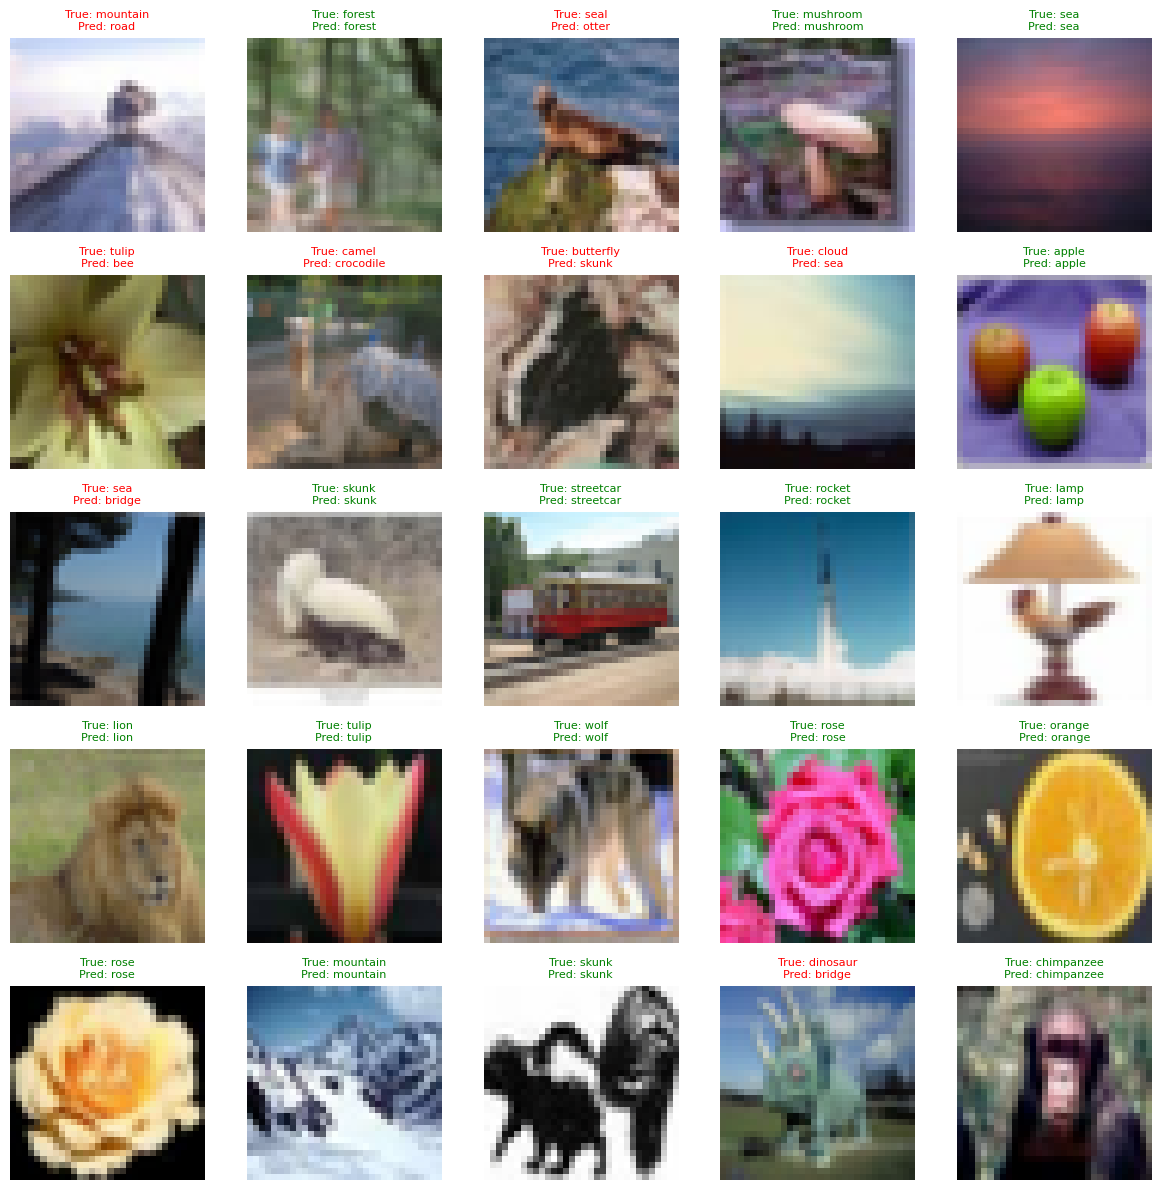

In [27]:
trained_model = train_model()

_, test_loader = get_cifar100_loaders(64)
visualize_predictions(trained_model, test_loader)